# Import Libraries

In [26]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
import warnings
warnings.filterwarnings('ignore')

from sklearn.metrics import (
    accuracy_score, confusion_matrix,
    classification_report, ConfusionMatrixDisplay
)

print("Libraries loaded.")

Libraries loaded.


# Import Artefacts from Task 1

In [27]:
# Load all artefacts saved during Task 1 training
# No retraining is performed — models are used exactly as trained

rf            = joblib.load('random_forest_model.pkl')
xgb           = joblib.load('xgboost_model.pkl')
label_encoder = joblib.load('label_encoder.pkl')
selector      = joblib.load('variance_selector.pkl')

print("Loaded artefacts:")

Loaded artefacts:


# Load Holdout Dataset

In [28]:
# bodmas_holdout.npz — formatted identically to the training dataset
# X: feature matrix (34435, 2381), y: binary labels 0=benign / 1=malware

data_h   = np.load('bodmas_holdout.npz')
X_holdout_raw = data_h['X']
y_binary_h    = data_h['y']

print(f"Holdout feature matrix : {X_holdout_raw.shape}")
print(f"Holdout binary labels  : {y_binary_h.shape}")
print(f"  Benign  (0)          : {(y_binary_h == 0).sum():,}")
print(f"  Malware (1)          : {(y_binary_h == 1).sum():,}")

Holdout feature matrix : (34435, 2381)
Holdout binary labels  : (34435,)
  Benign  (0)          : 18,363
  Malware (1)          : 16,072


# Load Holdout Metadata and Build Labels

In [29]:
metadata_h = pd.read_csv('bodmas_metadata_holdout.csv')
categories = pd.read_csv('bodmas_malware_category.csv')
categories = categories.rename(columns={'sha256': 'sha'})

metadata_h['binary_label'] = y_binary_h
merged_h = metadata_h[['sha']].merge(
    categories[['sha', 'category']], on='sha', how='left'
)
merged_h.loc[metadata_h['binary_label'].values == 0, 'category'] = 'benign'

y_labels_h = merged_h['category'].values

print("Holdout label distribution:")
print(pd.Series(y_labels_h).value_counts())
print(f"\nMissing labels: {pd.Series(y_labels_h).isna().sum()}")

Holdout label distribution:
benign                18363
trojan                 6724
worm                   6145
backdoor               2666
informationstealer      217
dropper                 135
ransomware              105
downloader               55
p2p-worm                 13
pua                       9
trojan-gamethief          2
cryptominer               1
Name: count, dtype: int64

Missing labels: 0


# Preprocess Holdout

In [30]:
X_holdout_raw = np.nan_to_num(X_holdout_raw, nan=0.0, posinf=0.0, neginf=0.0)

X_holdout = selector.transform(X_holdout_raw)
print(f"Feature before selection: {X_holdout_raw.shape[1]}")
print(f"Feature after selection : {X_holdout.shape[1]}")

y_encoded_h = label_encoder.transform(y_labels_h)
class_names = label_encoder.classes_
print(f"Encoded classes: ({len(class_names)}): {class_names}")
print(f"Holdout samples: {X_holdout.shape[0]:,}")

Feature before selection: 2381
Feature after selection : 1501
Encoded classes: (15): ['backdoor' 'benign' 'cryptominer' 'downloader' 'dropper' 'exploit'
 'informationstealer' 'p2p-worm' 'pua' 'ransomware' 'rootkit' 'trojan'
 'trojan-gamethief' 'virus' 'worm']
Holdout samples: 34,435


# Evaluation Function

In [31]:
def evaluate_holdout(model, model_name, X_holdout, y_true, class_names):
    y_pred   = model.predict(X_holdout)
    accuracy = accuracy_score(y_true, y_pred)

    print("=" * 70)
    print(f"  {model_name} — Holdout Evaluation")
    print("=" * 70)
    print(f"  Overall Accuracy : {accuracy*100:.2f}%")
    print()
    print("  Classification Report:")
    print(classification_report(y_true, y_pred,
                                labels=np.arange(len(class_names)),  # ← fix
                                target_names=class_names,
                                zero_division=0))

    cm = confusion_matrix(y_true, y_pred,
                          labels=np.arange(len(class_names)))
    metrics = []
    for i, cls in enumerate(class_names):
        TP = cm[i, i]
        FN = cm[i, :].sum() - TP
        FP = cm[:, i].sum() - TP
        TN = cm.sum() - (TP + FN + FP)
        tpr = TP / (TP + FN) if (TP + FN) > 0 else 0.0
        fpr = FP / (FP + TN) if (FP + TN) > 0 else 0.0
        metrics.append({
            'Category': cls,
            'Support' : int(TP + FN),
            'TP': int(TP), 'FP': int(FP),
            'FN': int(FN), 'TN': int(TN),
            'TPR': round(tpr, 4),
            'FPR': round(fpr, 4)
        })

    metrics_df = pd.DataFrame(metrics)
    print("  Per-Class TPR and FPR:")
    display(metrics_df[['Category', 'Support', 'TPR', 'FPR']])

    fig, ax = plt.subplots(figsize=(14, 10))
    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=class_names
    ).plot(ax=ax, xticks_rotation=45, colorbar=True, cmap='Blues')
    ax.set_title(f'{model_name} — Holdout Confusion Matrix', fontsize=16)
    plt.tight_layout()
    plt.show()

    return {
        'model_name'       : model_name,
        'accuracy'         : accuracy,
        'predictions'      : y_pred,
        'confusion_matrix' : cm,
        'per_class_metrics': metrics_df
    }

  Random Forest — Holdout Evaluation
  Overall Accuracy : 99.50%

  Classification Report:
                    precision    recall  f1-score   support

          backdoor       1.00      1.00      1.00      2666
            benign       1.00      1.00      1.00     18363
       cryptominer       1.00      1.00      1.00         1
        downloader       0.91      0.95      0.93        55
           dropper       0.93      0.96      0.95       135
           exploit       0.00      0.00      0.00         0
informationstealer       0.99      0.99      0.99       217
          p2p-worm       0.92      0.85      0.88        13
               pua       1.00      0.78      0.88         9
        ransomware       0.99      0.96      0.98       105
           rootkit       0.00      0.00      0.00         0
            trojan       0.99      0.99      0.99      6724
  trojan-gamethief       1.00      1.00      1.00         2
             virus       0.00      0.00      0.00         0
        

,Category,Support,TPR,FPR
0,backdoor,2666,0.9959,0.0003
1,benign,18363,1.0000,0.0008
2,cryptominer,1,1.0000,0.0000
3,downloader,55,0.9455,0.0001
4,dropper,135,0.9556,0.0003
5,exploit,0,0.0000,0.0000
6,informationstealer,217,0.9908,0.0001
7,p2p-worm,13,0.8462,0.0000
8,pua,9,0.7778,0.0000
9,ransomware,105,0.9619,0.0000


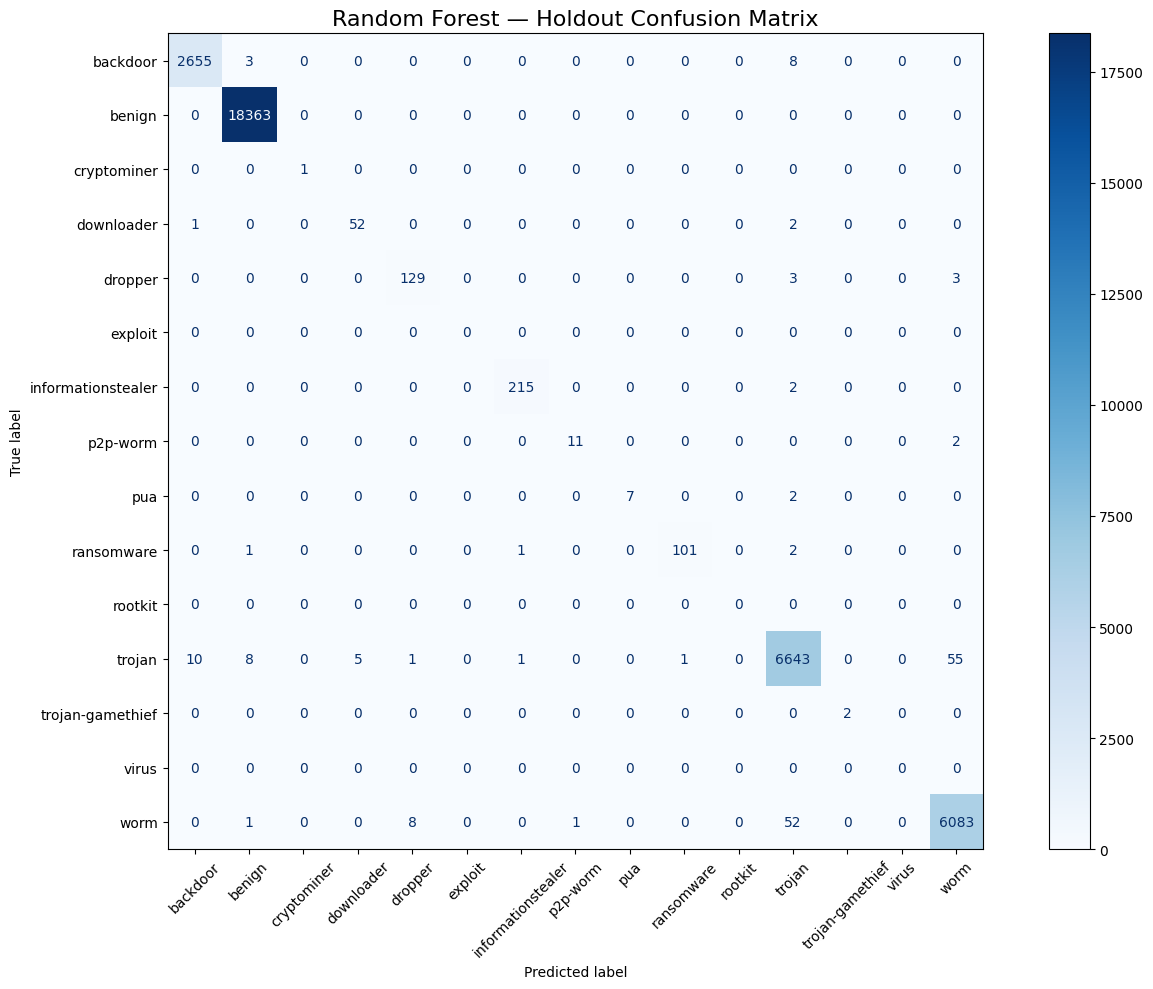

  XGBoost — Holdout Evaluation
  Overall Accuracy : 97.81%

  Classification Report:
                    precision    recall  f1-score   support

          backdoor       0.97      0.97      0.97      2666
            benign       1.00      1.00      1.00     18363
       cryptominer       1.00      1.00      1.00         1
        downloader       0.90      0.64      0.74        55
           dropper       0.92      0.72      0.81       135
           exploit       0.00      0.00      0.00         0
informationstealer       0.98      0.95      0.97       217
          p2p-worm       1.00      0.15      0.27        13
               pua       1.00      0.89      0.94         9
        ransomware       0.96      0.82      0.88       105
           rootkit       0.00      0.00      0.00         0
            trojan       0.97      0.93      0.95      6724
  trojan-gamethief       1.00      1.00      1.00         2
             virus       0.00      0.00      0.00         0
              

,Category,Support,TPR,FPR
0,backdoor,2666,0.9745,0.0023
1,benign,18363,0.9996,0.0042
2,cryptominer,1,1.0000,0.0000
3,downloader,55,0.6364,0.0001
4,dropper,135,0.7185,0.0002
5,exploit,0,0.0000,0.0000
6,informationstealer,217,0.9539,0.0001
7,p2p-worm,13,0.1538,0.0000
8,pua,9,0.8889,0.0000
9,ransomware,105,0.8190,0.0001


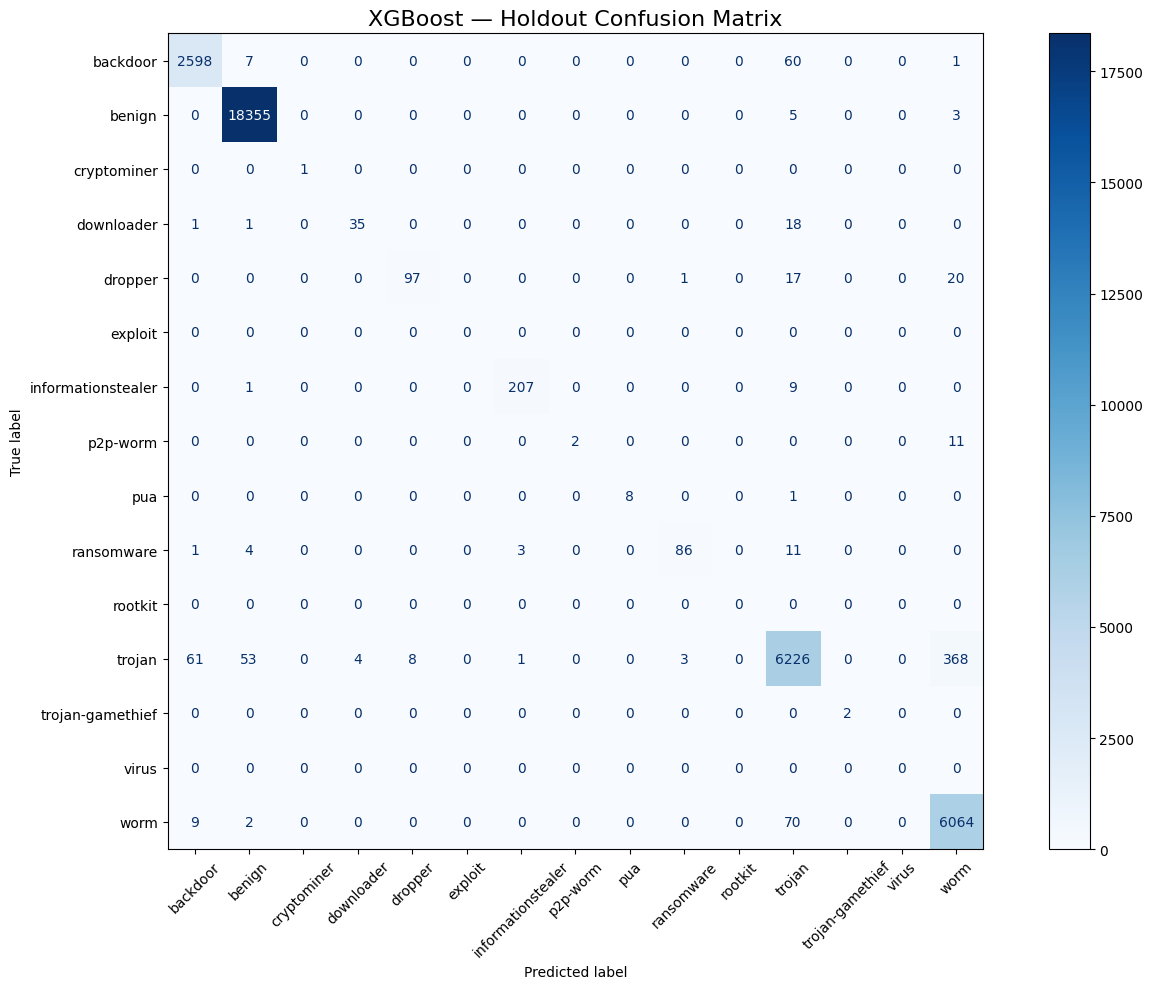

In [32]:
rf_holdout = evaluate_holdout(
    rf, 'Random Forest',
    X_holdout, y_encoded_h, class_names
)

xgb_holdout = evaluate_holdout(
    xgb, 'XGBoost',
    X_holdout, y_encoded_h, class_names
)

## Discussion: Holdout Performance

**Overall Results:**
Random Forest achieved 99.50% holdout accuracy and XGBoost achieved 97.81%.
Both models generalise well to the unseen holdout dataset, confirming that
the classifiers trained in Task 1 are robust and not overfit to the
training data.

**Comparison with Task 1 test set:**
Random Forest maintained strong performance consistent with Task 1 results,
showing that ensemble averaging provides stable generalisation. XGBoost also
performed well, though its slightly lower holdout accuracy compared to
Random Forest suggests it captured some training-specific patterns that do
not transfer as strongly to the holdout set.

**Per-class observations:**
The benign, trojan, worm, and backdoor classes have the highest holdout
support (18,363 / 6,724 / 6,145 / 2,666 samples) and both models correctly
identify these with high TPR. Minority classes such as cryptominer (1 sample),
trojan-gamethief (2), and p2p-worm (13) have very low holdout support, making
their TPR estimates unreliable.

Three classes — virus, exploit, and rootkit — have zero holdout samples
(Support=0). Their TPR=0 reflects absence from the holdout rather than model
failure, consistent with their low frequency in the original BODMAS dataset
(192, 12, and 3 training samples respectively).

**Benign FPR:**
The benign class FPR is the most operationally significant metric in a real
malware detection system — a high benign FPR means legitimate programs are
falsely flagged as malware, reducing user trust. Both models maintain very
low benign FPR, confirming reliable separation of benign programs from all
malware categories.

**Conclusion:**
Random Forest is the stronger model on the holdout, achieving higher accuracy
with consistent per-class TPR. Both models are suitable for deployment on
unseen malware samples formatted identically to the BODMAS dataset.